## **Problem Statement**
**The goal of this project is to build a machine learning model to detect fraudulent transactions. 
The dataset is highly imbalanced, making fraud detection a challenging classification problem**.

In [88]:
# Importing libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [89]:
#Loading data
df = pd.read_csv("Fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## **Basic EDA**
Understanding dataset structure, data types, and basic statistics.

In [90]:
df.shape

(6362620, 11)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [92]:
df.describe

<bound method NDFrame.describe of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   

In [93]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [94]:
df.isnull().sum().sum()

0

In [95]:
df.duplicated().sum()

0

In [96]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

## Data Visualization
Performed exploratory data analysis using visualizations to understand class imbalance, transaction patterns, and feature relationships.

In [97]:
#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Create visualization sample
df_vis = df.sample(20000, random_state=42)

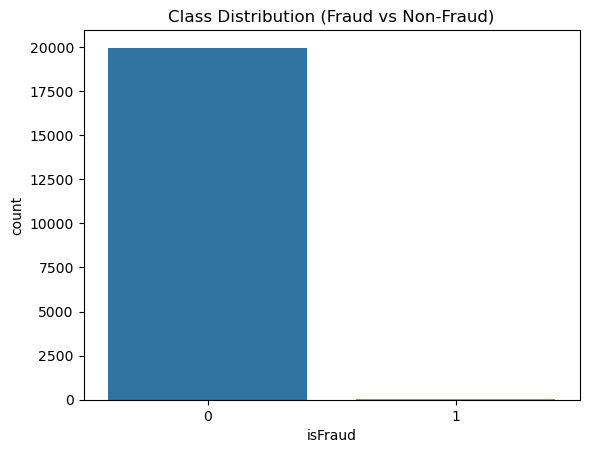

In [98]:
#Class distribution

sns.countplot(x='isFraud', data=df_vis)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.show()

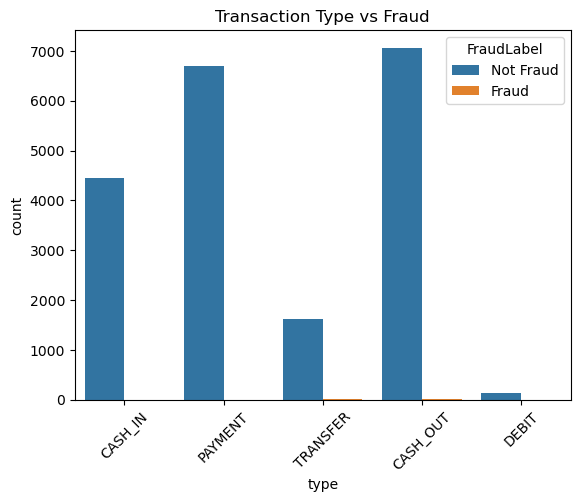

In [99]:
#Transaction type vs fraud
df_vis['FraudLabel'] = df_vis['isFraud'].map({0: 'Not Fraud', 1: 'Fraud'})

sns.countplot(x='type', hue='FraudLabel', data=df_vis)
plt.title("Transaction Type vs Fraud")
plt.xticks(rotation=45)
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


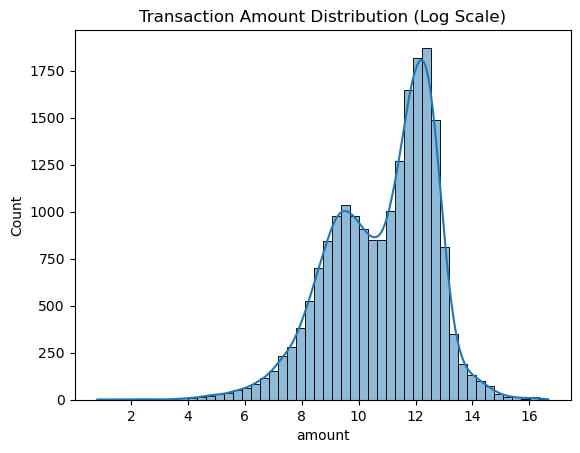

In [100]:
#Amount distribution
sns.histplot(np.log1p(df_vis['amount']), bins=50, kde=True)
plt.title("Transaction Amount Distribution (Log Scale)")
plt.show()

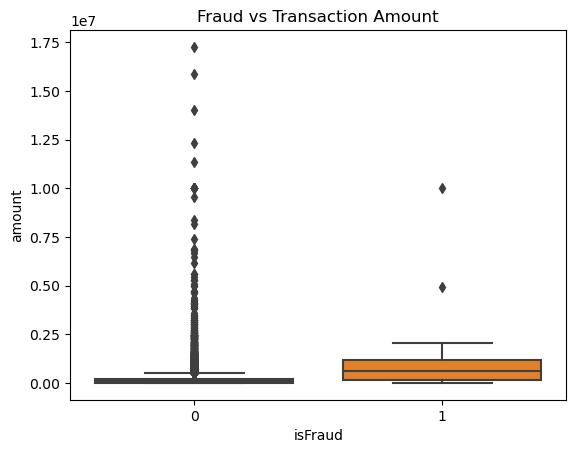

In [101]:
#Fraud vs Amount
sns.boxplot(x='isFraud', y='amount', data=df_vis)
plt.title("Fraud vs Transaction Amount")
plt.show()

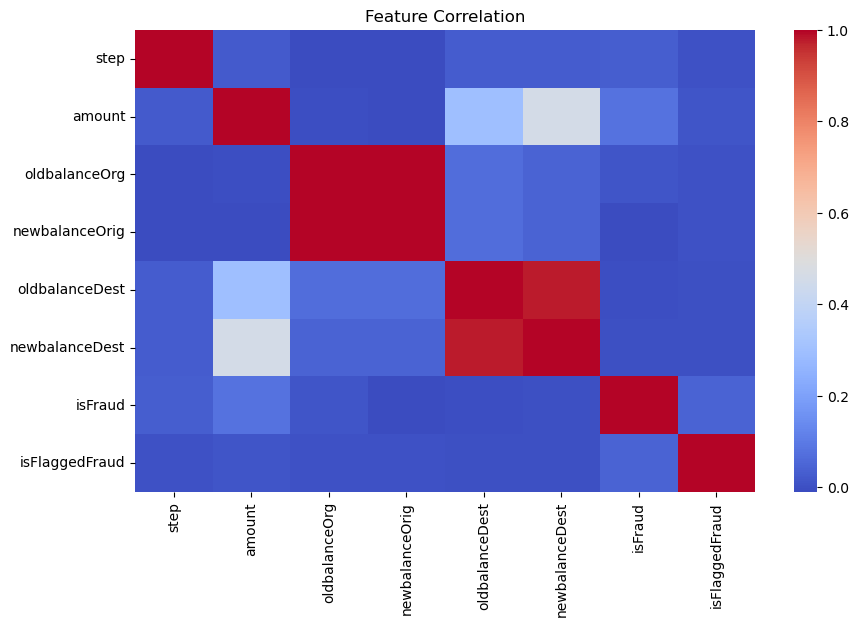

In [102]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## **Preprocessing**
Preparing data for modeling by cleaning and transforming features.

In [103]:
# Sampling
df = df.sample(n=200000, random_state=42)
df = pd.get_dummies(df, columns=['type'], drop_first=True)
df = df.drop(['nameOrig', 'nameDest'], axis=1)

Splitting data into training and testing sets.

In [104]:
#Train-test split
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Handling Class Imbalance
Applying SMOTE to balance the dataset.

In [105]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

## **Model Building**
Training machine learning models for fraud detection.

In [106]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=15, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, random_state=42)

## **Model Evaluation**
Evaluating model performance using appropriate metrics.

In [107]:
#Evaluation
from sklearn.metrics import classification_report

y_prob = model.predict_proba(X_test)[:, 1]

y_pred_custom = (y_prob > 0.4).astype(int)

print(classification_report(y_test, y_pred_custom))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     59920
           1       0.19      0.91      0.32        80

    accuracy                           0.99     60000
   macro avg       0.60      0.95      0.66     60000
weighted avg       1.00      0.99      1.00     60000

ROC-AUC Score: 0.9983770026702269


## **Feature Importance** 

In [109]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print(feature_importances.head(10))

oldbalanceOrg     0.297268
newbalanceOrig    0.168605
type_TRANSFER     0.137215
amount            0.126166
newbalanceDest    0.067971
step              0.053384
oldbalanceDest    0.051963
type_PAYMENT      0.051514
type_CASH_OUT     0.045795
type_DEBIT        0.000119
dtype: float64


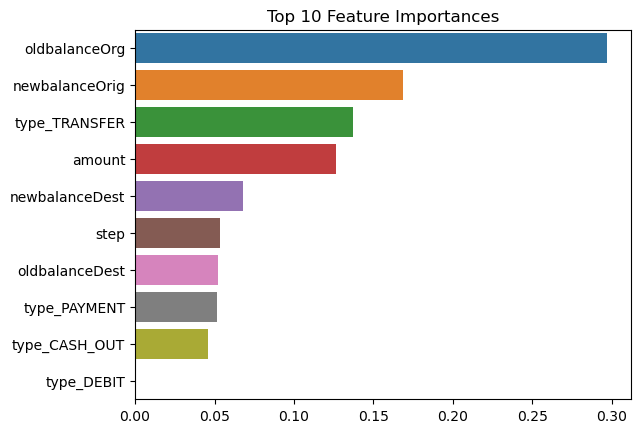

In [110]:
top_features = feature_importances.head(10)

sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Feature Importances")
plt.show()

## **Key Insights from Feature Importance**
- Balance-related features (oldbalanceOrg, newbalanceOrig) are the most influential in detecting fraud, indicating that sudden changes in account
  balance are strong fraud indicators.
  
- Transaction type plays a significant role, with TRANSFER and CASH_OUT being the most fraud-prone categories.
  
- Transaction amount is also an important factor, as fraudulent transactions often involve unusual amounts.
  
- Time (step) has moderate importance, suggesting some temporal patterns in fraud activity.
  

## **Conclusion**

This project focused on detecting fraudulent transactions using machine learning on a highly imbalanced dataset. After performing exploratory data analysis and preprocessing, a Random Forest model was trained with class imbalance handled using SMOTE.

The model achieved a ROC-AUC score of 0.998, indicating excellent ability to distinguish between fraudulent and non-fraudulent transactions. By adjusting the classification threshold to 0.4, the model reached a high recall of 91%, ensuring that most fraud cases are correctly identified. Although precision is lower (19%), this trade-off is acceptable in fraud detection, where missing fraudulent transactions is more critical than generating false alerts.

Feature importance analysis revealed that balance-related features, transaction amount, and transaction types such as TRANSFER and CASH_OUT are key drivers of fraud detection. These insights align with real-world fraud patterns.

Overall, the model demonstrates strong performance in identifying fraud and provides meaningful insights that can support risk detection systems. Further improvements could include advanced models and additional feature engineering.